In [1]:
import torch
print(torch.cuda.is_available())

True


Полный ноутбук содержит встроенные принты v-llm по разметке 1000 картинок и логи обучения на каждой эпохе, которые не переводятся в файл и не отключаются. В связи с чем, ноут весит 42 мб. Ссылка на полный ноутбук тут:
https://colab.research.google.com/drive/1EAAxVz_uMAMVAtHlgzJMLyvzE5aq6L4d?usp=sharing  

Ссылка на нотубук на янд диске https://disk.yandex.ru/d/zSyeelC-Y6okFA

ССылка на гит: https://github.com/bigdatacon/YA_SPR_FIN/tree/first

Данный ноутбук предназначен для сдачи (не более 10 мб) содержит только первую часть и ссылки коллаб и яндекс диск на полный ноутбук


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Всего изображений: 1001


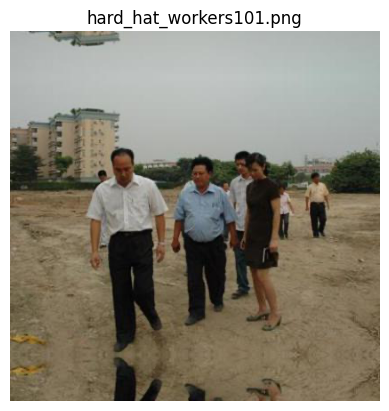

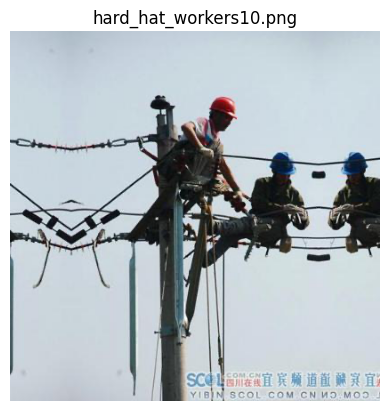

In [3]:
import os
import matplotlib.pyplot as plt
from PIL import Image

image_dir = "/content/drive/MyDrive/images"

images = os.listdir(image_dir)

print("Всего изображений:", len(images))

# Покажем несколько картинок
for i in range(2):
    img_path = os.path.join(image_dir, images[i])
    img = Image.open(img_path)

    plt.imshow(img)
    plt.title(images[i])
    plt.axis("off")
    plt.show()

Картинки не большого размера. На некоторых данные скучены, что приведет к ошибкам при формировании boundin boxes.

Сначала размечу и отрисую картинку средствами трансформера, без пакетной обработки

In [4]:
!pip install qwen-vl-utils
from transformers import Qwen2_5_VLForConditionalGeneration, AutoTokenizer, AutoProcessor
from qwen_vl_utils import process_vision_info

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
  "Qwen/Qwen2.5-VL-7B-Instruct"

)
processor = AutoProcessor.from_pretrained("Qwen/Qwen2.5-VL-7B-Instruct")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 68.4 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

...

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [5]:
PROMPT = """
Detect all people in the image.

For each person:
- if wearing a helmet → label = helmet
- if NOT wearing a helmet → label = no_helmet

Return ONLY JSON:
[
  {"bbox_2d": [x1, y1, x2, y2], "label": "helmet"},
  {"bbox_2d": [x1, y1, x2, y2], "label": "no_helmet"}
]
"""

In [6]:
from transformers import TextStreamer

streamer = TextStreamer(processor.tokenizer, skip_prompt=True)



messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": "/content/drive/MyDrive/images/hard_hat_workers94.png",
            },
            {"type": "text", "text": PROMPT},
        ],
    }
]


text = processor.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True
)
image_inputs, video_inputs = process_vision_info(messages)
inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
)
inputs = inputs.to(model.device)


generated_ids = model.generate(
    **inputs,
    max_new_tokens=128,
    streamer=streamer
)
generated_ids_trimmed = [
    out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]
output_text = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)
print(output_text)

```json
[
  {"bbox_2d": [189, 115, 420, 415], "label": "helmet"}
]
```<|im_end|>
['```json\n[\n  {"bbox_2d": [189, 115, 420, 415], "label": "helmet"}\n]\n```']



Отрисую разметку на 1 картинке

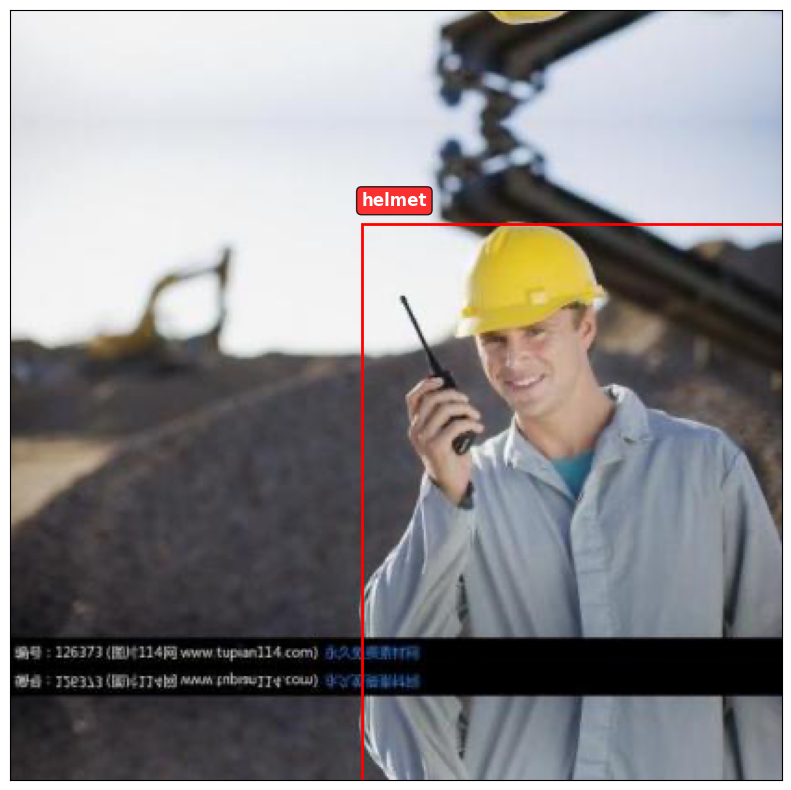

In [7]:
import json
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np


def simple_json_parse(json_data):
    if isinstance(json_data, list):
        json_str = json_data[0]
    else:
        json_str = json_data

    # удаляем сгенерированный markdown
    json_str = json_str.replace('```json', '').replace('```', '')
    json_str = json_str.strip()

    return json.loads(json_str)

result = simple_json_parse(output_text[0]) # 0 - т.к. тексты в листе

def plot_image_with_bbox(image_path, predictions, font_size=12, line_width=2,
                         text_color='white', box_color='red'):
    # загружаем картинку
    image = Image.open(image_path)
    img_array = np.array(image)

    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    ax.imshow(img_array)

    # визуализируем боксы
    for p in predictions:
        x1, y1, x2, y2 = p["bbox_2d"]
        width = x2 - x1
        height = y2 - y1

        # добавим bbox
        rect = patches.Rectangle(
            (x1, y1), width, height,
            linewidth=line_width, edgecolor=box_color, facecolor='none'
        )
        ax.add_patch(rect)

        # добавим лэйблы
        ax.text(
            x1, y1 - 10, p["label"],
            fontsize=font_size, color=text_color, weight='bold',
            bbox=dict(boxstyle="round,pad=0.3", facecolor=box_color, alpha=0.8)
        )

        ax.set_xticks([])
        ax.set_yticks([])

    plt.tight_layout()
    plt.show()

image_path = "/content/drive/MyDrive/images/hard_hat_workers94.png"

plot_image_with_bbox(image_path, result)

Закончен предварительный этап. Модель определяет шлем и отрисовывает но довольно медленно. Для качественного решения данной задачи необходимо разметить каждую картинку именно таким способом (выше), не пакетно, но это очень долго. Поэтому я создал небольшую папку из 8 картинок которую размечу таким образом - чтобы посмотреть насколько такая разметка качественнее чем пакетная.

Необязательный эксперимент: разметка небольшого кол-ва картинок обычным трансформером

In [8]:
import os
import json
from PIL import Image
import glob
from tqdm import tqdm
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor, TextStreamer
from qwen_vl_utils import process_vision_info

# -----------------------------
# Пути
# -----------------------------
images_path = "/content/drive/MyDrive/images_small"
labels_path = "/content/drive/MyDrive/labels_vlm_small"
os.makedirs(labels_path, exist_ok=True)
# Удаляем все файлы внутри папки
for f in glob.glob(os.path.join(labels_path, "*")):
    os.remove(f)
# -----------------------------
# Модель и процессор
# -----------------------------
model = Qwen2_5_VLForConditionalGeneration.from_pretrained("Qwen/Qwen2.5-VL-7B-Instruct")
processor = AutoProcessor.from_pretrained("Qwen/Qwen2.5-VL-7B-Instruct")

# -----------------------------
# YOLO label mapping
# -----------------------------
label_map = {"helmet": 0, "no_helmet": 1}

# -----------------------------
# Вспомогательные функции
# -----------------------------
def fix_json(text):
    text = text.replace('```json','').replace('```','').strip()
    if "]" in text:
        text = text[:text.rfind("]")+1]
    return text

def safe_parse(text):
    try:
        return json.loads(text)
    except:
        try:
            return json.loads(fix_json(text))
        except:
            return None

def convert_to_yolo(bbox, w, h):
    x1, y1, x2, y2 = bbox
    xc = (x1 + x2) / 2 / w
    yc = (y1 + y2) / 2 / h
    bw = (x2 - x1) / w
    bh = (y2 - y1) / h
    return xc, yc, bw, bh

# -----------------------------
# TextStreamer для визуального прогресса
# -----------------------------
streamer = TextStreamer(processor.tokenizer, skip_prompt=True)

# -----------------------------
# Основной цикл по картинкам
# -----------------------------
image_files = [
    f for f in os.listdir(images_path)
    if f.lower().endswith((".jpg", ".png", ".jpeg"))
]

print(f"[INFO] Found {len(image_files)} images")

for img_name in tqdm(image_files):
    img_path = os.path.join(images_path, img_name)
    try:
        print(f"[INFO] Processing: {img_name}")

        # --- создаём сообщения ---
        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": img_path},
                    {"type": "text", "text": PROMPT},
                ],
            }
        ]

        text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        image_inputs, video_inputs = process_vision_info(messages)
        inputs = processor(
            text=[text],
            images=image_inputs,
            videos=video_inputs,
            padding=True,
            return_tensors="pt",
        ).to(model.device)

        # --- генерация ---
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=256,
            streamer=streamer
        )

        # --- обрезка prompt токенов ---
        generated_ids_trimmed = [
            out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
        ]

        output_text = processor.batch_decode(
            generated_ids_trimmed,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=False
        )[0]

        # --- парсинг JSON ---
        annotations = safe_parse(output_text)
        if annotations is None:
            print(f"[WARNING] Bad JSON for {img_name}, skipping")
            continue

        # --- сохраняем YOLO ---
        img = Image.open(img_path)
        w, h = img.size
        label_file = os.path.join(labels_path, img_name.rsplit(".",1)[0] + ".txt")

        with open(label_file, "w") as f:
            for obj in annotations:
                if "bbox_2d" not in obj:
                    continue
                label = obj.get("label")
                if label not in label_map:
                    continue
                xc, yc, bw, bh = convert_to_yolo(obj["bbox_2d"], w, h)
                f.write(f"{label_map[label]} {xc} {yc} {bw} {bh}\n")

        print(f"[SUCCESS] Saved {label_file}")

    except Exception as e:
        print(f"[ERROR] {img_name}: {e}")

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

[INFO] Found 8 images


  0%|          | 0/8 [00:00<?, ?it/s]

[INFO] Processing: hard_hat_workers0.png
```json
[
  {"bbox_2d": [340, 119, 420, 415], "label": "helmet"},
  {"bbox_2d": [278, 146, 364, 327], "label": "no_helmet"},
  {"bbox_2d": [245, 151, 292, 317], "label": "no_helmet"},
  {"bbox_2d": [153, 158, 230, 330], "label": "no_helmet"},
  {"bbox_2d": [194, 149, 249, 293], "label": "no_helmet"},
  {"bbox_2d": [108, 157, 154, 304], "label": "no_helmet"},
  {"bbox_2d": [97, 143, 121, 293], "label": "no_helmet"},
  {"bbox_2d": [5


...

[SUCCESS] Saved /content/drive/MyDrive/labels_vlm_small/hard_hat_workers5.txt
[INFO] Processing: hard_hat_workers6.png
```json
[
  {"bbox_2d": [70, 153, 104, 196], "label": "helmet"},
  {"bbox_2d": [124, 168, 146, 190], "label": "helmet"}
]
```<|im_end|>


 88%|████████▊ | 7/8 [11:04<01:17, 77.43s/it]

[SUCCESS] Saved /content/drive/MyDrive/labels_vlm_small/hard_hat_workers6.txt
[INFO] Processing: hard_hat_workers7.png
```json
[
  {"bbox_2d": [304, 98, 420, 415], "label": "helmet"},
  {"bbox_2d": [336, 140, 370, 180], "label": "helmet"}
]
```<|im_end|>


100%|██████████| 8/8 [12:22<00:00, 92.84s/it]

[SUCCESS] Saved /content/drive/MyDrive/labels_vlm_small/hard_hat_workers7.txt


Отрисую картинки - размеченные не пакетной обработкой

[WARNING] Нет разметки: hard_hat_workers0.png
[INFO] Showing: hard_hat_workers1.png


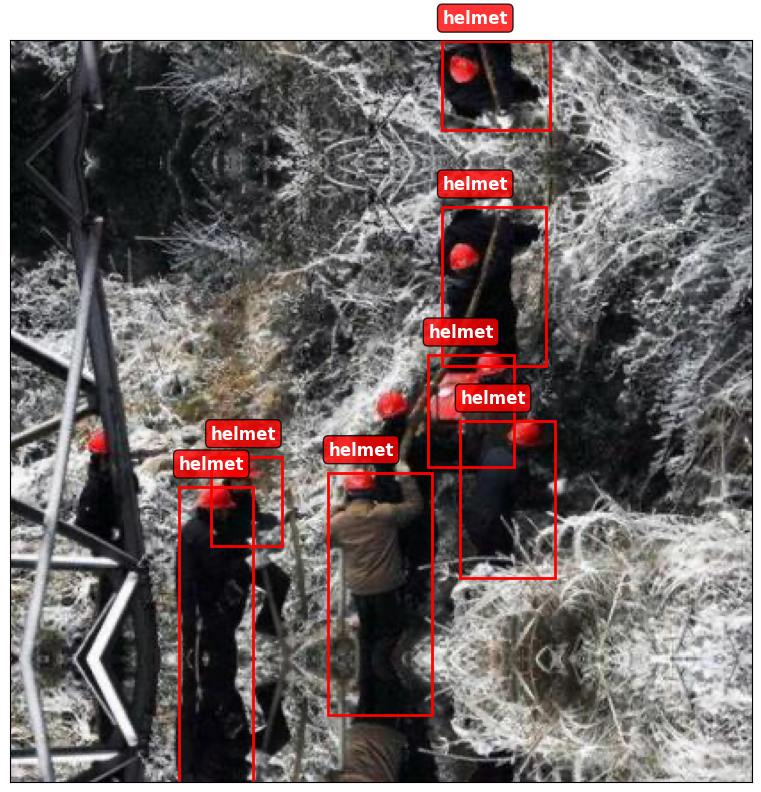

[INFO] Showing: hard_hat_workers2.png


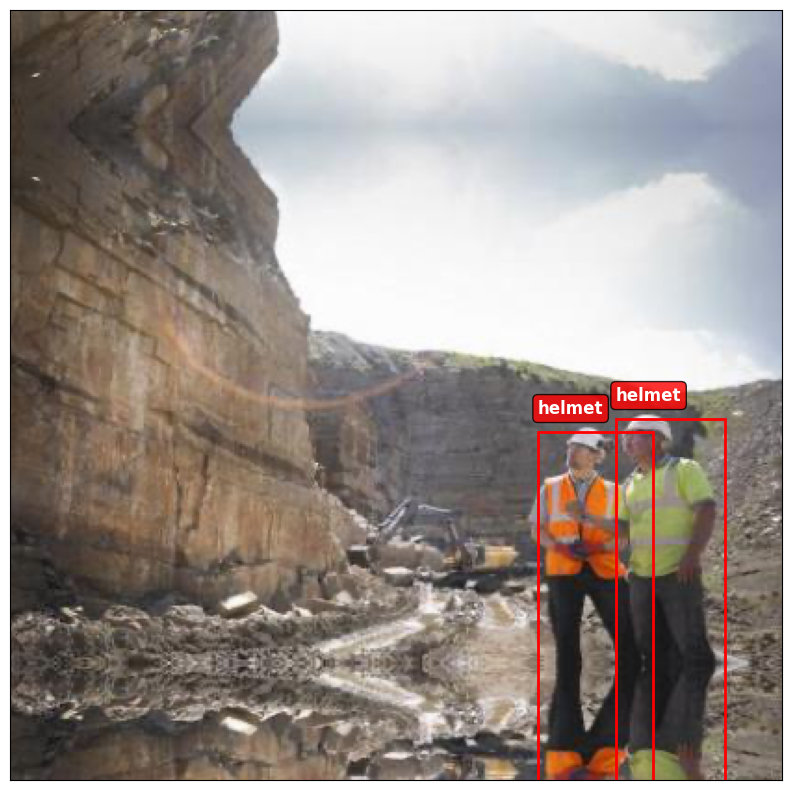

[INFO] Showing: hard_hat_workers3.png


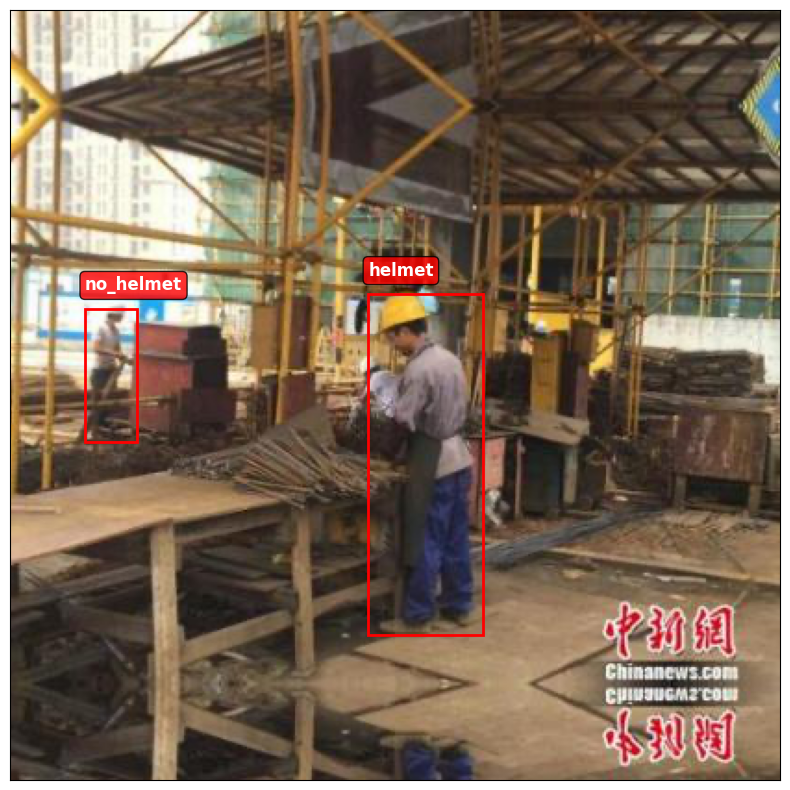

[INFO] Showing: hard_hat_workers4.png


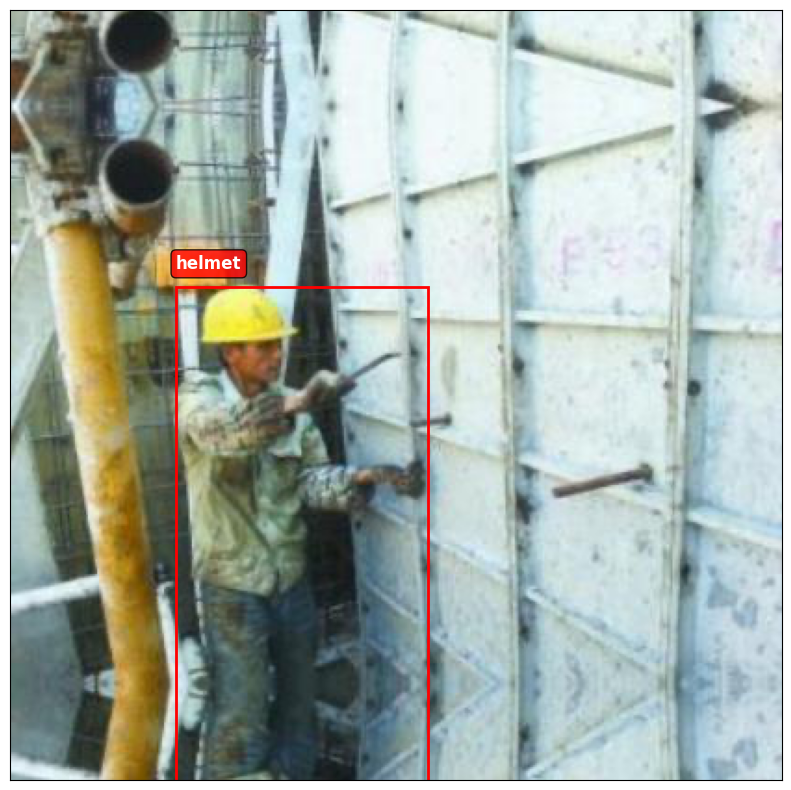

[INFO] Showing: hard_hat_workers5.png


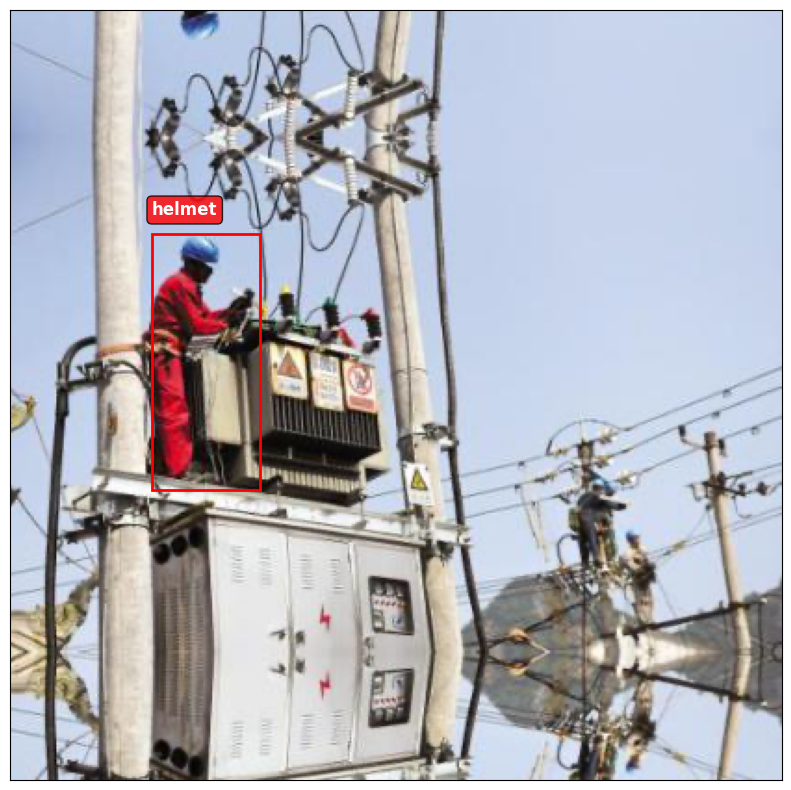

[INFO] Showing: hard_hat_workers6.png


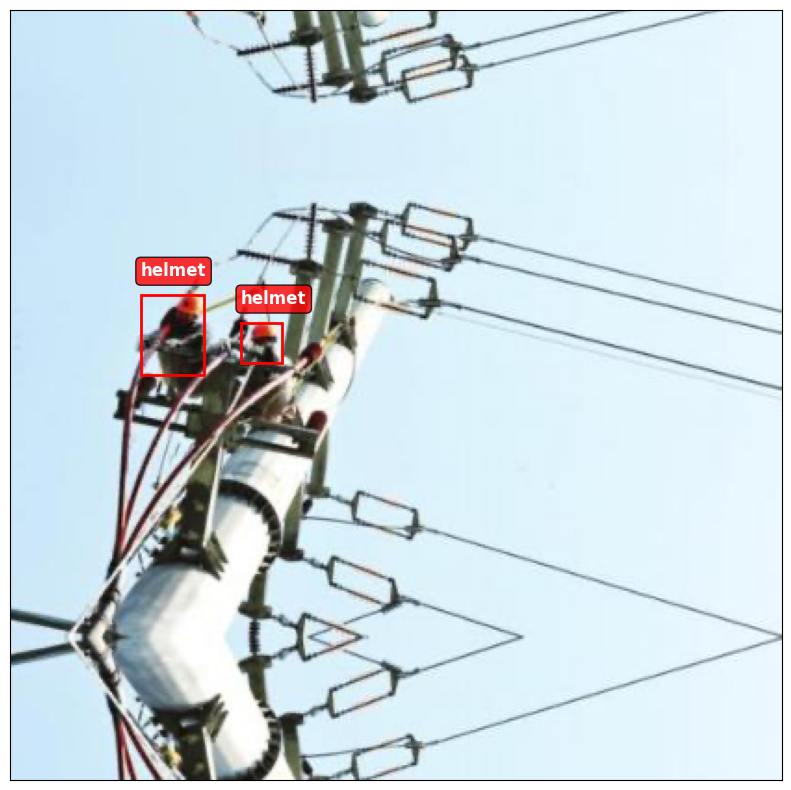

[INFO] Showing: hard_hat_workers7.png


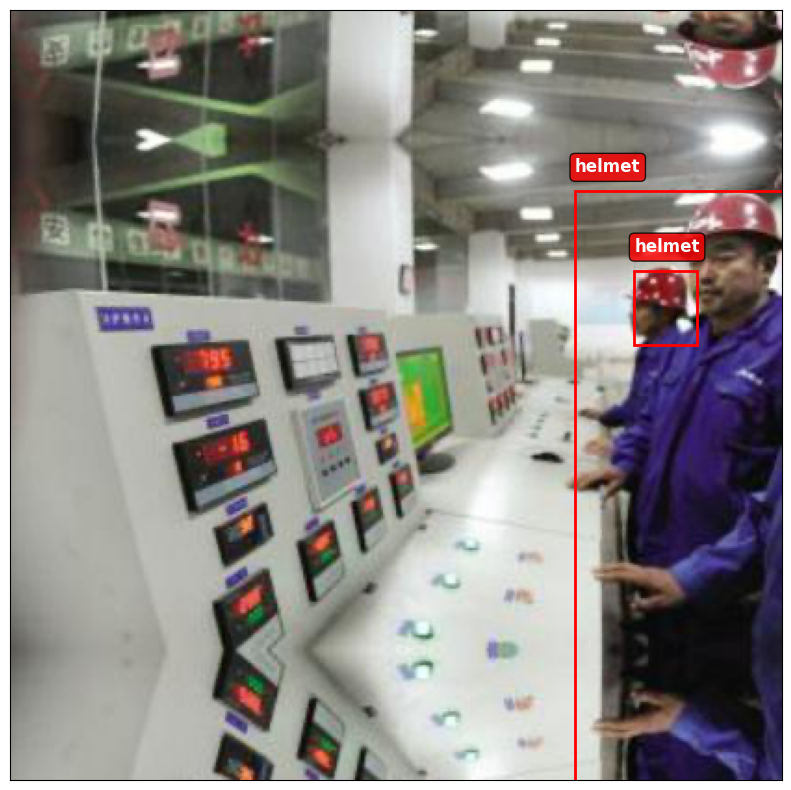

In [9]:
import os

images_path = "/content/drive/MyDrive/images_small"
# labels_path = "/content/drive/MyDrive/labels"
labels_path = "/content/drive/MyDrive/labels_vlm_small"

label_map_rev = {0: "helmet", 1: "no_helmet"}

def yolo_to_bbox(label_path, image_path):
    image = Image.open(image_path)
    w, h = image.size

    predictions = []

    with open(label_path) as f:
        for line in f:
            cls, xc, yc, bw, bh = map(float, line.split())

            x1 = int((xc - bw/2) * w)
            y1 = int((yc - bh/2) * h)
            x2 = int((xc + bw/2) * w)
            y2 = int((yc + bh/2) * h)

            predictions.append({
                "bbox_2d": [x1, y1, x2, y2],
                "label": label_map_rev[int(cls)]
            })

    return predictions


# берём 3 изображения
image_files = [
    f for f in os.listdir(images_path)
    if f.endswith((".jpg", ".png", ".jpeg"))
]

for img_name in image_files:
    img_path = os.path.join(images_path, img_name)
    label_path = os.path.join(labels_path, img_name.rsplit(".",1)[0] + ".txt")

    if not os.path.exists(label_path):
        print(f"[WARNING] Нет разметки: {img_name}")
        continue

    print(f"[INFO] Showing: {img_name}")

    preds = yolo_to_bbox(label_path, img_path)

    plot_image_with_bbox(img_path, preds)

Видно что качество разметки очень высокое, 1 ошибка на 8 картинок. Такое решение оптимально для пром разработки - то есть оставить на пару суток процесс, чтобы он разметил 1000 картинок таким способом. Но в учебных целях это не реально. Поэтому далее в этом направлении углубляться не буду, сделал это чтобы просто оценить разницу в качестве.

Полный ноутбук содержит встроенные принты v-llm по разметке 1000 картинок и логи обучения на каждой эпохе, которые не переводятся в файл и не отключаются. В связи с чем, ноут весит 42 мб. Ссылка на полный ноутбук тут: https://colab.research.google.com/drive/1EAAxVz_uMAMVAtHlgzJMLyvzE5aq6L4d?usp=sharing

Ссылка на нотубук на янд диске https://disk.yandex.ru/d/zSyeelC-Y6okFA

ССылка на гит: https://github.com/bigdatacon/YA_SPR_FIN/tree/first

Данный ноутбук предназначен для сдачи (не более 10 мб) содержит только первую часть и ссылки коллаб и яндекс диск на полный ноутбук